# Mouse Dynamics Bot Detection - Part 1: Data Exploration

This notebook explores the M4D Mouse Dynamics dataset containing mouse movement data from humans, moderate bots, and advanced bots.

**Dataset Source**: Iliou et al., 2021 - "Detection of Advanced Web Bots by Combining Web Logs with Mouse Behavioural Biometrics"

In [17]:
# Import libraries
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Paths
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data/phase1")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")

Base directory: /Users/karennurlybekov/Desktop/mousedynamics
Data directory: /Users/karennurlybekov/Desktop/mousedynamics/data/phase1


## 1. Load Dataset Annotations

In [18]:
def load_annotations(filepath):
    """Load annotation file and return dict of session_id -> label"""
    annotations = {}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                if len(parts) >= 2:
                    session_id, label = parts[0], parts[1]
                    annotations[session_id] = label
    return annotations

# Load all annotations
adv_train = load_annotations(os.path.join(DATA_DIR, "annotations/humans_and_advanced_bots/train"))
adv_test = load_annotations(os.path.join(DATA_DIR, "annotations/humans_and_advanced_bots/test"))
mod_train = load_annotations(os.path.join(DATA_DIR, "annotations/humans_and_moderate_bots/train"))
mod_test = load_annotations(os.path.join(DATA_DIR, "annotations/humans_and_moderate_bots/test"))

# Combine all annotations
all_annotations = {}
all_annotations.update(adv_train)
all_annotations.update(adv_test)
all_annotations.update(mod_train)
all_annotations.update(mod_test)

print(f"Advanced bots dataset: {len(adv_train)} train, {len(adv_test)} test")
print(f"Moderate bots dataset: {len(mod_train)} train, {len(mod_test)} test")
print(f"Total unique sessions: {len(all_annotations)}")

Advanced bots dataset: 70 train, 30 test
Moderate bots dataset: 70 train, 30 test
Total unique sessions: 150



Label Distribution:
  advanced_bot: 50
  human: 50
  moderate_bot: 50


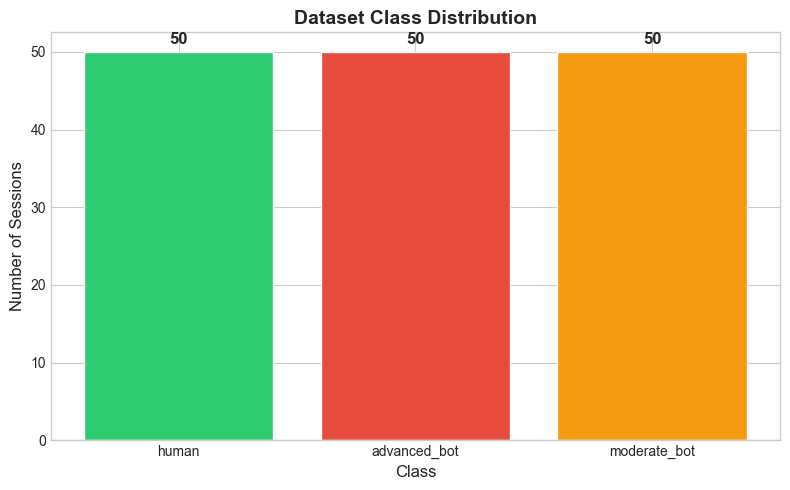

In [19]:
# Count by label
label_counts = defaultdict(int)
for label in all_annotations.values():
    label_counts[label] += 1

print("\nLabel Distribution:")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
labels = list(label_counts.keys())
counts = list(label_counts.values())
colors = ['#2ecc71', '#e74c3c', '#f39c12']
ax.bar(labels, counts, color=colors)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Sessions', fontsize=12)
ax.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
for i, (label, count) in enumerate(zip(labels, counts)):
    ax.text(i, count + 1, str(count), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Parse Mouse Movement Data

In [20]:
def parse_mouse_movements(behavior_string):
    """Parse the total_behaviour string into list of events"""
    events = []
    # Pattern matches m(x,y) for moves and c(l), c(r), s(d), s(u) for other events
    pattern = r'\[(m|c|s)\(([^)]+)\)\]'
    matches = re.findall(pattern, behavior_string)

    for event_type, params in matches:
        if event_type == 'm':
            coords = params.split(',')
            if len(coords) == 2:
                try:
                    x, y = int(coords[0]), int(coords[1])
                    events.append({'type': 'move', 'x': x, 'y': y})
                except ValueError:
                    pass
        elif event_type == 'c':
            events.append({'type': 'click', 'button': params})
        elif event_type == 's':
            events.append({'type': 'scroll', 'direction': params})

    return events

def load_session_data(session_id):
    """Load mouse movement data for a session"""
    paths = [
        os.path.join(DATA_DIR, f"data/mouse_movements/humans_and_advanced_bots/{session_id}/mouse_movements.json"),
        os.path.join(DATA_DIR, f"data/mouse_movements/humans_and_moderate_bots/{session_id}/mouse_movements.json")
    ]

    for path in paths:
        if os.path.exists(path):
            with open(path, 'r') as f:
                data = json.load(f)
                return parse_mouse_movements(data.get('total_behaviour', ''))
    return None

In [21]:
# Load all sessions
sessions_data = {}
for session_id, label in all_annotations.items():
    events = load_session_data(session_id)
    if events:
        sessions_data[session_id] = {
            'events': events,
            'label': label
        }

print(f"Successfully loaded {len(sessions_data)} sessions")

Successfully loaded 150 sessions


## 3. Examine Raw Data Format

In [22]:
# Look at sample events from each class
for label in ['human', 'moderate_bot', 'advanced_bot']:
    print(f"\n{'='*60}")
    print(f"Sample {label.upper()} events (first 20):")
    print('='*60)
    
    for sid, data in sessions_data.items():
        if data['label'] == label:
            for event in data['events'][:20]:
                print(event)
            break


Sample HUMAN events (first 20):
{'type': 'move', 'x': 246, 'y': 6}
{'type': 'move', 'x': 244, 'y': 9}
{'type': 'move', 'x': 239, 'y': 18}
{'type': 'move', 'x': 235, 'y': 26}
{'type': 'move', 'x': 231, 'y': 35}
{'type': 'move', 'x': 223, 'y': 43}
{'type': 'move', 'x': 215, 'y': 50}
{'type': 'move', 'x': 208, 'y': 55}
{'type': 'move', 'x': 197, 'y': 63}
{'type': 'move', 'x': 189, 'y': 70}
{'type': 'move', 'x': 181, 'y': 82}
{'type': 'move', 'x': 176, 'y': 95}
{'type': 'move', 'x': 172, 'y': 109}
{'type': 'move', 'x': 172, 'y': 129}
{'type': 'move', 'x': 174, 'y': 143}
{'type': 'move', 'x': 178, 'y': 157}
{'type': 'move', 'x': 180, 'y': 163}
{'type': 'move', 'x': 182, 'y': 168}
{'type': 'move', 'x': 185, 'y': 171}
{'type': 'move', 'x': 188, 'y': 174}

Sample MODERATE_BOT events (first 20):
{'type': 'move', 'x': 0, 'y': 4}
{'type': 'move', 'x': 0, 'y': 5}
{'type': 'move', 'x': 0, 'y': 6}
{'type': 'move', 'x': 0, 'y': 7}
{'type': 'move', 'x': 1, 'y': 8}
{'type': 'move', 'x': 1, 'y': 9}
{'t

## 4. Summary Statistics

In [23]:
# Compute statistics by class
stats_by_class = defaultdict(list)

for session_id, data in sessions_data.items():
    events = data['events']
    label = data['label']

    move_events = [e for e in events if e['type'] == 'move']
    click_events = [e for e in events if e['type'] == 'click']
    scroll_events = [e for e in events if e['type'] == 'scroll']

    stats_by_class[label].append({
        'session_id': session_id,
        'total_events': len(events),
        'move_events': len(move_events),
        'click_events': len(click_events),
        'scroll_events': len(scroll_events)
    })

In [24]:
# Display statistics
print("Summary Statistics by Class:")
print("=" * 70)

summary_data = []
for label in ['human', 'moderate_bot', 'advanced_bot']:
    if label in stats_by_class:
        session_stats = stats_by_class[label]
        n_sessions = len(session_stats)
        total_events = [s['total_events'] for s in session_stats]
        move_events = [s['move_events'] for s in session_stats]
        click_events = [s['click_events'] for s in session_stats]

        print(f"\n{label.upper()}:")
        print(f"  Sessions: {n_sessions}")
        print(f"  Total events: mean={np.mean(total_events):.1f}, std={np.std(total_events):.1f}, "
              f"min={np.min(total_events)}, max={np.max(total_events)}")
        print(f"  Move events: mean={np.mean(move_events):.1f}, std={np.std(move_events):.1f}")
        print(f"  Click events: mean={np.mean(click_events):.1f}, std={np.std(click_events):.1f}")
        
        summary_data.append({
            'Class': label,
            'Sessions': n_sessions,
            'Mean Events': np.mean(total_events),
            'Std Events': np.std(total_events),
            'Mean Moves': np.mean(move_events),
            'Mean Clicks': np.mean(click_events)
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

Summary Statistics by Class:

HUMAN:
  Sessions: 50
  Total events: mean=10879.4, std=3222.3, min=5484, max=17997
  Move events: mean=10716.3, std=3174.1
  Click events: mean=12.6, std=2.8

MODERATE_BOT:
  Sessions: 50
  Total events: mean=3994.0, std=1579.2, min=1422, max=8173
  Move events: mean=3980.5, std=1577.4
  Click events: mean=13.2, std=2.7

ADVANCED_BOT:
  Sessions: 50
  Total events: mean=7382.5, std=2506.8, min=1469, max=13958
  Move events: mean=7366.8, std=2504.6
  Click events: mean=15.3, std=3.0


,Class,Sessions,Mean Events,Std Events,Mean Moves,Mean Clicks
0,human,50,10879.40,3222.264980,10716.30,12.58
1,moderate_bot,50,3994.00,1579.187487,3980.52,13.22
2,advanced_bot,50,7382.48,2506.798574,7366.80,15.32


## 5. Visualize Mouse Trajectories

In [25]:
def get_trajectory(events):
    """Extract x,y coordinates from move events"""
    moves = [(e['x'], e['y']) for e in events if e['type'] == 'move']
    if not moves:
        return [], []
    x, y = zip(*moves)
    return list(x), list(y)

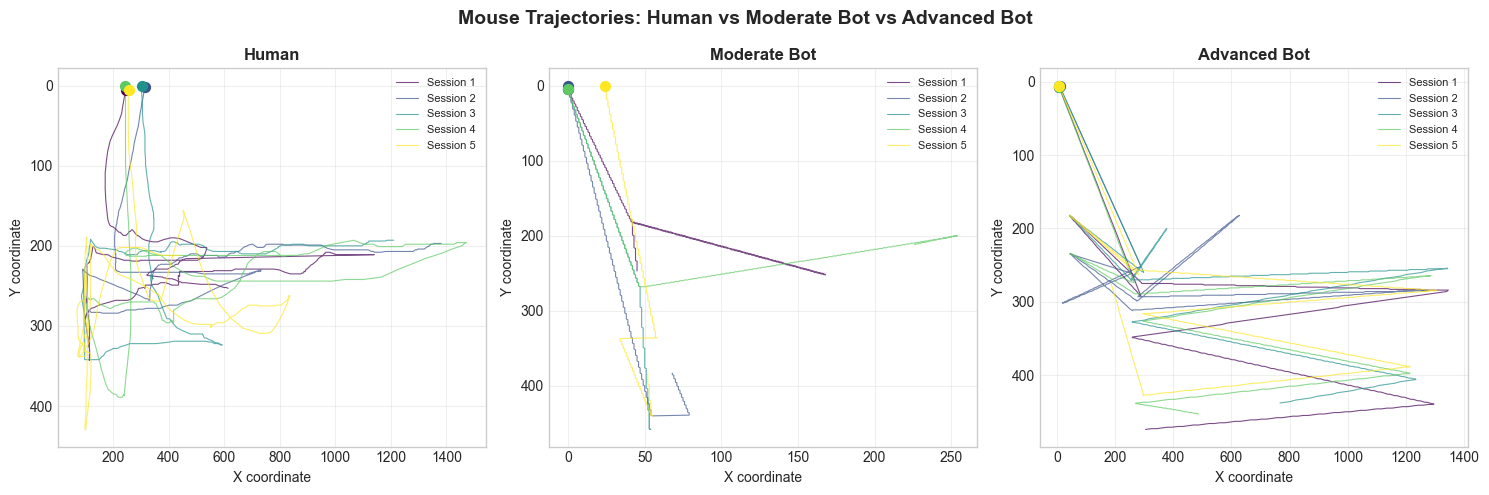

In [26]:
# Plot example trajectories side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels_to_plot = ['human', 'moderate_bot', 'advanced_bot']

for idx, label in enumerate(labels_to_plot):
    ax = axes[idx]
    sessions_for_label = [(sid, d) for sid, d in sessions_data.items() if d['label'] == label]

    # Plot 5 example trajectories
    colors = plt.cm.viridis(np.linspace(0, 1, 5))
    for i, (sid, data) in enumerate(sessions_for_label[:5]):
        x, y = get_trajectory(data['events'])
        if x and y:
            ax.plot(x[:500], y[:500], alpha=0.7, linewidth=0.8, color=colors[i], label=f'Session {i+1}')
            ax.scatter(x[0], y[0], color=colors[i], s=50, marker='o', zorder=5)  # Start point

    ax.set_title(f'{label.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.invert_yaxis()  # Invert Y since screen coordinates go down
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Mouse Trajectories: Human vs Moderate Bot vs Advanced Bot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'trajectories_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### Observations from Trajectories

- **Human**: Irregular, curved movements with natural variations
- **Moderate Bot**: Very regular, almost pixel-by-pixel linear movements
- **Advanced Bot**: More varied than moderate, but still unnaturally geometric patterns

## 6. Event Count Distributions

In [27]:
# Prepare data for plotting
event_counts_df = []
for label in ['human', 'moderate_bot', 'advanced_bot']:
    if label in stats_by_class:
        for s in stats_by_class[label]:
            event_counts_df.append({
                'label': label,
                'total_events': s['total_events'],
                'move_events': s['move_events']
            })
event_counts_df = pd.DataFrame(event_counts_df)

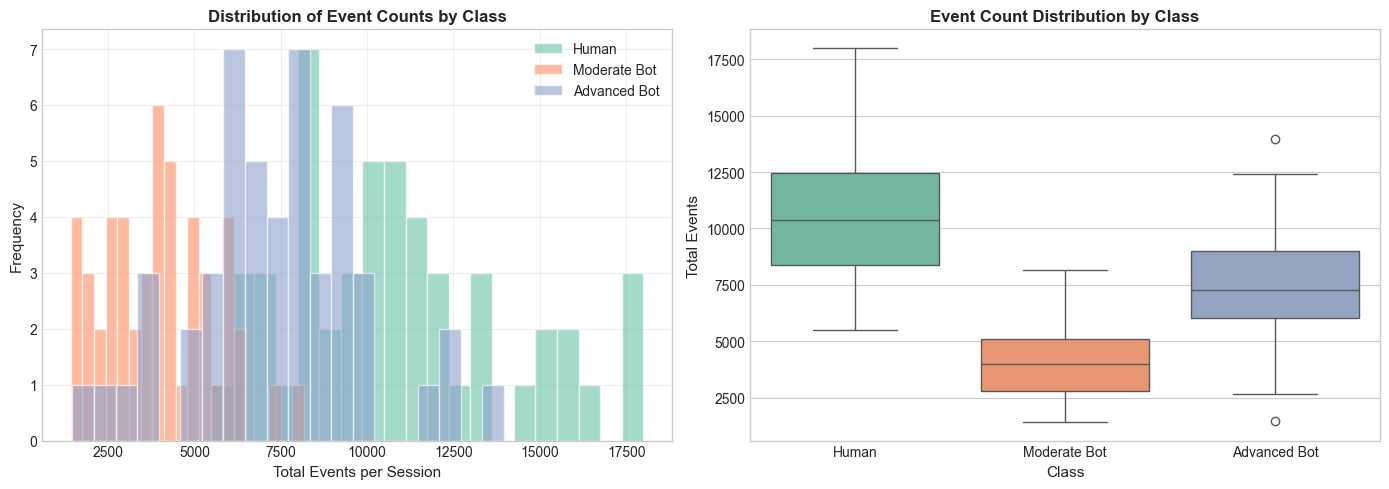

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
for label in ['human', 'moderate_bot', 'advanced_bot']:
    subset = event_counts_df[event_counts_df['label'] == label]['total_events']
    ax.hist(subset, bins=20, alpha=0.6, label=label.replace('_', ' ').title())
ax.set_xlabel('Total Events per Session', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Event Counts by Class', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot
ax = axes[1]
order = ['human', 'moderate_bot', 'advanced_bot']
sns.boxplot(data=event_counts_df, x='label', y='total_events', order=order, ax=ax, palette='Set2')
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Total Events', fontsize=11)
ax.set_title('Event Count Distribution by Class', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Human', 'Moderate Bot', 'Advanced Bot'])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'event_count_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Mouse Position Heatmaps

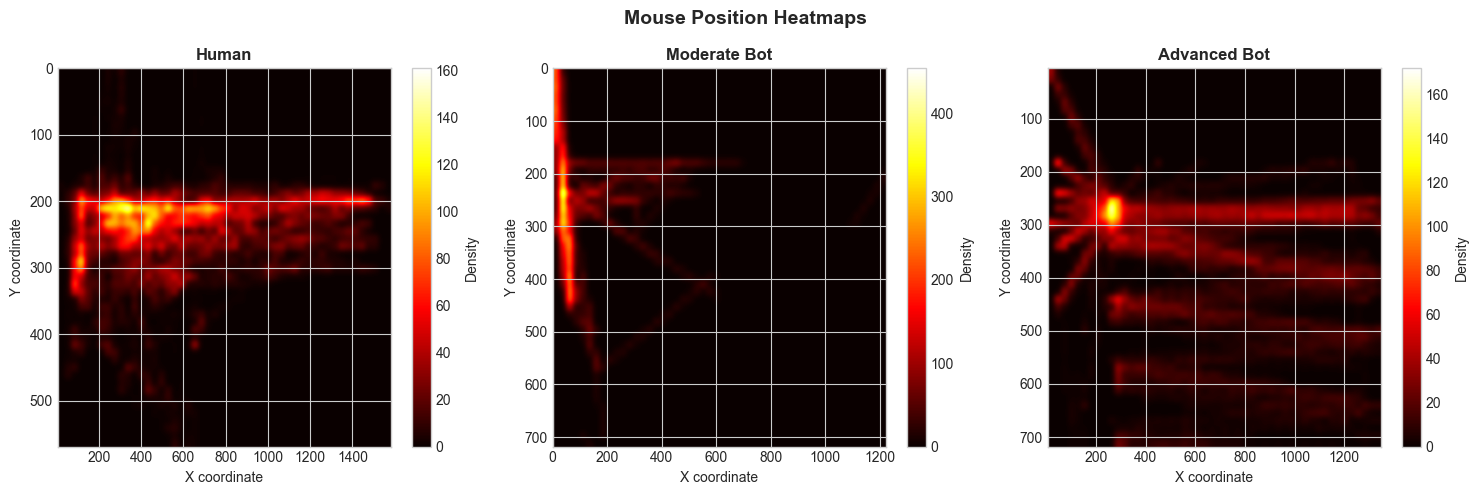

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, label in enumerate(['human', 'moderate_bot', 'advanced_bot']):
    ax = axes[idx]
    sessions_for_label = [(sid, d) for sid, d in sessions_data.items() if d['label'] == label]

    # Collect all positions
    all_x, all_y = [], []
    for sid, data in sessions_for_label[:20]:  # Use first 20 sessions
        x, y = get_trajectory(data['events'])
        all_x.extend(x[:1000])  # Limit points per session
        all_y.extend(y[:1000])

    if all_x and all_y:
        # Create 2D histogram (heatmap)
        h, xedges, yedges = np.histogram2d(all_x, all_y, bins=50)
        im = ax.imshow(h.T, extent=[xedges[0], xedges[-1], yedges[-1], yedges[0]],
                       cmap='hot', aspect='auto', interpolation='gaussian')
        plt.colorbar(im, ax=ax, label='Density')

    ax.set_title(f'{label.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')

plt.suptitle('Mouse Position Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'position_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Movement Pattern Analysis

In [30]:
def analyze_movement_steps(events):
    """Analyze step sizes between consecutive points"""
    moves = [(e['x'], e['y']) for e in events if e['type'] == 'move']
    if len(moves) < 2:
        return []
    
    x = np.array([m[0] for m in moves])
    y = np.array([m[1] for m in moves])
    
    dx = np.diff(x)
    dy = np.diff(y)
    distances = np.sqrt(dx**2 + dy**2)
    
    return distances

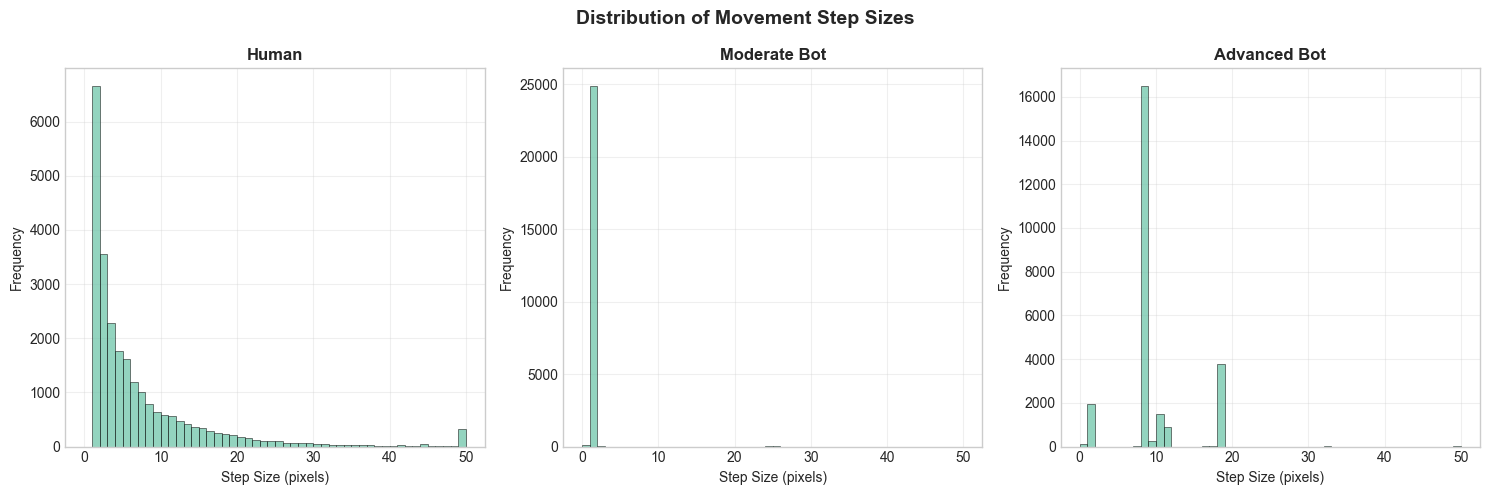


Key Observation:
- Moderate bots show very uniform step sizes (often single-pixel increments)
- Advanced bots have more varied but still regular patterns
- Humans show natural variation with a wider distribution


In [31]:
# Analyze step size distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, label in enumerate(['human', 'moderate_bot', 'advanced_bot']):
    ax = axes[idx]
    
    all_distances = []
    for sid, data in sessions_data.items():
        if data['label'] == label:
            distances = analyze_movement_steps(data['events'])
            all_distances.extend(distances[:500])  # Limit per session
    
    if all_distances:
        # Limit to reasonable range for visualization
        distances_clipped = np.clip(all_distances, 0, 50)
        ax.hist(distances_clipped, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    ax.set_title(f'{label.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Step Size (pixels)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Movement Step Sizes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("- Moderate bots show very uniform step sizes (often single-pixel increments)")
print("- Advanced bots have more varied but still regular patterns")
print("- Humans show natural variation with a wider distribution")

## 9. Save Processed Data

In [32]:
# Save sessions data for next notebook
import pickle

with open(os.path.join(OUTPUT_DIR, 'sessions_data.pkl'), 'wb') as f:
    pickle.dump(sessions_data, f)

print(f"Saved {len(sessions_data)} sessions to sessions_data.pkl")

Saved 150 sessions to sessions_data.pkl


## Summary

### Dataset Overview
- **150 total sessions**: 50 human, 50 moderate bot, 50 advanced bot
- **Balanced dataset** suitable for classification

### Key Differences Observed

| Feature | Human | Moderate Bot | Advanced Bot |
|---------|-------|--------------|-------------|
| Avg Events | ~10,900 | ~4,000 | ~7,400 |
| Trajectory | Curved, irregular | Linear, uniform | Geometric patterns |
| Step Size | Variable | Very uniform (~1px) | Regular (~8px) |

### Next Steps
Continue to **Part 2: Feature Engineering** to extract meaningful features from this data.